In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df=pd.read_csv(r"C:\Users\cathr\Downloads\archive (8)\AmesHousing.csv")
display(df.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
print(df.shape)
df.info()

(2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  Hou

In [4]:
print(df.isnull().sum().sort_values(ascending=False).head(20))
print("Duplicates:",df.duplicated().sum())
display(df.describe(include='all').T)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64
Duplicates: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,2930.0,NaN,NaN,NaN,1465.5,845.96247,1.0,733.25,1465.5,2197.75,2930.0
PID,2930.0,NaN,NaN,NaN,714464496.988737,188730844.64939,526301100.0,528477022.5,535453620.0,907181097.5,1007100110.0
MS SubClass,2930.0,NaN,NaN,NaN,57.387372,42.638025,20.0,20.0,50.0,70.0,190.0
MS Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2440.0,NaN,NaN,NaN,69.22459,23.365335,21.0,58.0,68.0,80.0,313.0
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,2930.0,NaN,NaN,NaN,6.216041,2.714492,1.0,4.0,6.0,8.0,12.0
Yr Sold,2930.0,NaN,NaN,NaN,2007.790444,1.316613,2006.0,2007.0,2008.0,2009.0,2010.0
Sale Type,2930,10,WD,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2930,6,Normal,2413,NaN,NaN,NaN,NaN,NaN,NaN,NaN


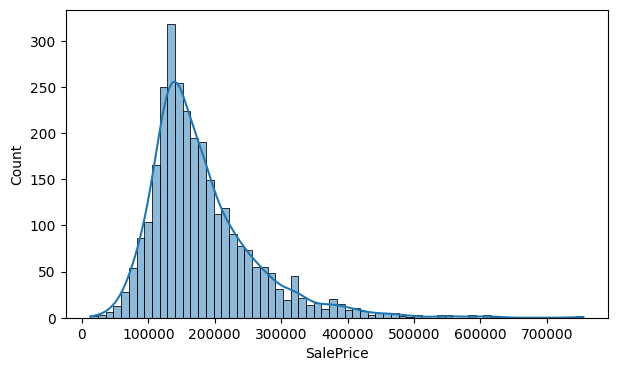

In [5]:
plt.figure(figsize=(7,4))
sns.histplot(df["SalePrice"],kde=True)
plt.show()

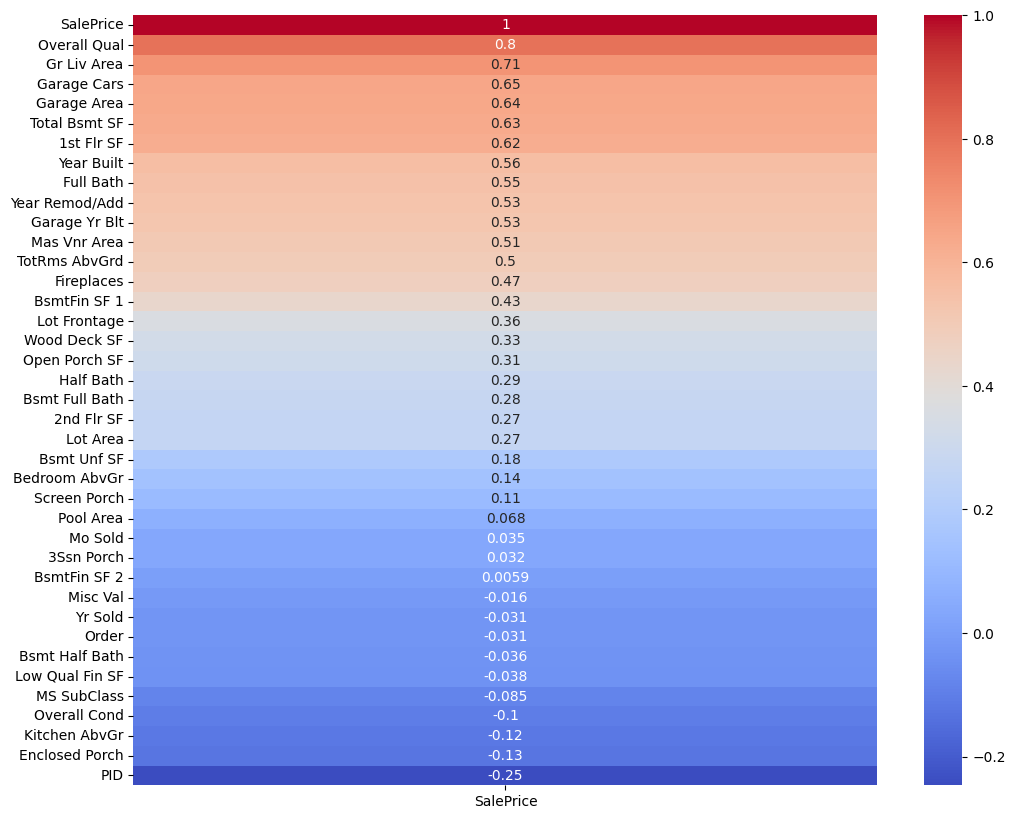

In [6]:
num=df.select_dtypes(include=np.number)
plt.figure(figsize=(12,10))
sns.heatmap(num.corr()[["SalePrice"]].sort_values(by="SalePrice",ascending=False),annot=True,cmap="coolwarm")
plt.show()


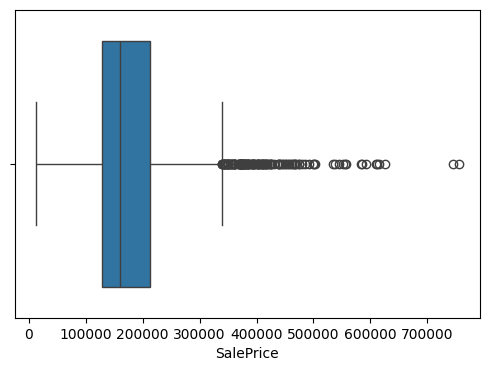

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["SalePrice"])
plt.show()

In [8]:
df=df.drop_duplicates()
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]


In [9]:
num_cols=X.select_dtypes(include=np.number).columns
cat_cols=X.select_dtypes(exclude=np.number).columns

pre=ColumnTransformer([
("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),num_cols),
("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cat_cols)
])


In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
lr=Pipeline([("pre",pre),("model",LinearRegression())])
lr.fit(X_train,y_train)
p1=lr.predict(X_test)

In [12]:
dt=Pipeline([("pre",pre),("model",DecisionTreeRegressor(max_depth=10,random_state=42))])
dt.fit(X_train,y_train)
p2=dt.predict(X_test)

In [13]:
results=pd.DataFrame({
"Model":["Linear Regression","Decision Tree"],
"MAE":[mean_absolute_error(y_test,p1),mean_absolute_error(y_test,p2)],
"RMSE":[np.sqrt(mean_squared_error(y_test,p1)),np.sqrt(mean_squared_error(y_test,p2))],
"R2":[r2_score(y_test,p1),r2_score(y_test,p2)]
})
display(results)


,Model,MAE,RMSE,R2
0,Linear Regression,16034.107897,29635.358986,0.890458
1,Decision Tree,23256.615632,34334.413051,0.852966
